In [1]:
!pip install --quiet  -r req-fine-models.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.1/60.1 MB 42.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 88.3 MB/s eta 0:00:00


In [2]:
##Importante tener cuenta en hugging face, para algunos modelos como meta/llama
# se debe tener aprobacion para descargar desde la plataforma el modelo.
from huggingface_hub import login
login(new_session=False)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


In [3]:
import os
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

In [4]:
import numpy as np
import pandas as pd
import torch
from torch.nn.utils.rnn import pad_sequence
import transformers
from tqdm import tqdm
from transformers import AutoModelForCausalLM, AutoTokenizer, set_seed,BitsAndBytesConfig
from peft import LoraConfig, get_peft_model,prepare_model_for_kbit_training
import random
from datasets import Dataset
from pathlib import Path
from sklearn.model_selection import train_test_split
from pathlib import Path
from tqdm.auto import tqdm
DATA_RAW = Path("./data-sources/raw")
DATA_PREPR = Path("./data-sources/pre-processed")
DATA_RAW.mkdir(parents=True, exist_ok=True)
DATA_PREPR.mkdir(parents=True, exist_ok=True)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [5]:
RANDOM_SEED = 42
set_seed(RANDOM_SEED)
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
torch.cuda.manual_seed_all(RANDOM_SEED)

In [6]:
#df = pd.read_csv(DATA_PREPR/"data_finetuning.csv")
#if 'name' in df.columns:
#    df = df.drop(columns=['name'])

##Por la prueba

#df_train, df_temp = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)

# crea una máscara con el conteo de "tokens" por espacio
#mask = df['article'].fillna('').astype(str).apply(lambda x: len(x.split())) <= 800

#df = df.loc[mask].reset_index(drop=True)

##Por la prueba

#df_train, df_temp = train_test_split(df, test_size=0.2, random_state=42, shuffle=True)
#df_test, df_val = train_test_split(df_temp, test_size=0.5, random_state=42, shuffle=True)

df_train = pd.read_csv(DATA_PREPR/"data_finetuning_train.csv")
df_val = pd.read_csv(DATA_PREPR/"data_finetuning_val.csv")
df_test = pd.read_csv(DATA_PREPR/"data_finetuning_test.csv")

print(f'Registros totales cargados para entrenamiento: {len(df_train)}')
print(f'Registros totales cargados para validacion: {len(df_val)}')
print(f'Registros totales cargados para test: {len(df_test)}')

Registros totales cargados para entrenamiento: 3030
Registros totales cargados para validacion: 379
Registros totales cargados para test: 379


In [7]:
def generar_prompt(cientific_text):
    input_text = f"""You are a helpful medical/health writer.
Summarize the following scientific text into a clear summary intented for a general audience.
Do NOT use headings, titles, bullet points, or numbered lists. Do not invent data or references.
If you must use a technical term, briefly define it.


Cientific Text: {cientific_text}


PLS Text:"""
    return input_text

In [8]:
tokenizer = AutoTokenizer.from_pretrained("meta-llama/Llama-3.2-1B")
tokenizer.pad_token = tokenizer.eos_token

tokenizer_config.json:   0%|          | 0.00/50.5k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/9.09M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/301 [00:00<?, ?B/s]

In [9]:
lora_config = LoraConfig(
    r=4,
    lora_alpha=16,
    target_modules=['k_proj', 'q_proj', 'v_proj', 'o_proj'],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM"
)
quant_4bit = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=(torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16))

tunned_model = AutoModelForCausalLM.from_pretrained(
    "meta-llama/Llama-3.2-1B",
    #attn_implementation="flash_attention_2",
    dtype=(torch.bfloat16 if torch.cuda.is_bf16_supported() else torch.float16),
    quantization_config=quant_4bit, device_map='auto')

tunned_model.config.use_cache = False
tunned_model.config.pad_token_id = tokenizer.pad_token_id
tunned_model = prepare_model_for_kbit_training(tunned_model, use_gradient_checkpointing=True)
tunned_model.gradient_checkpointing_enable()

tunned_model = get_peft_model(tunned_model, lora_config)


print("modelo:", getattr(tunned_model, "name_or_path", type(tunned_model)))
print("is_loaded_in_4bit:", getattr(tunned_model, "is_loaded_in_4bit", False))
print("is_loaded_in_8bit:", getattr(tunned_model, "is_loaded_in_8bit", False))
print("dtype params:", next(tunned_model.parameters()).dtype)
print("PEFT activo:", hasattr(tunned_model, "peft_config"))
tunned_model.print_trainable_parameters()

config.json:   0%|          | 0.00/843 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/2.47G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/185 [00:00<?, ?B/s]

modelo: meta-llama/Llama-3.2-1B
is_loaded_in_4bit: True
is_loaded_in_8bit: False
dtype params: torch.float32
PEFT activo: True
trainable params: 851,968 || all params: 1,236,666,368 || trainable%: 0.0689


In [10]:
MAX_CONTEXT_WINDOW = getattr(tunned_model.config, "max_position_embeddings", 4096)

In [11]:
def tokenize_with_labels(
    example,
    max_source_tokens: int = 2048,
    max_target_tokens: int = 1024,
    add_bos: bool = True,
):
    src_text = (example.get("article") or "").strip()
    tgt_text = (example.get("summary") or "").strip()


    prompt = generar_prompt(src_text)


    eos_tok = tokenizer.eos_token or ""
    target_with_eos = tgt_text + eos_tok


    src = tokenizer(prompt, add_special_tokens=False, truncation=True, max_length=max_source_tokens)
    tgt = tokenizer(target_with_eos, add_special_tokens=False, truncation=True, max_length=max_target_tokens)

    src_ids = src["input_ids"]
    tgt_ids = tgt["input_ids"]


    bos_extra = 1 if add_bos and tokenizer.bos_token_id is not None else 0
    total_len = len(src_ids) + len(tgt_ids) + bos_extra
    if total_len > MAX_CONTEXT_WINDOW:

        keep_src = max(1, MAX_CONTEXT_WINDOW - bos_extra - len(tgt_ids))
        src_ids = src_ids[:keep_src]
        total_len = len(src_ids) + len(tgt_ids) + bos_extra

        if total_len > MAX_CONTEXT_WINDOW:
            keep_tgt = max(1, MAX_CONTEXT_WINDOW - bos_extra - len(src_ids))
            tgt_ids = tgt_ids[:keep_tgt]

    input_ids = src_ids + tgt_ids
    labels    = ([-100] * len(src_ids)) + tgt_ids
    attn_mask = [1] * len(input_ids)


    if add_bos and tokenizer.bos_token_id is not None:
        input_ids  = [tokenizer.bos_token_id] + input_ids
        labels     = [-100] + labels
        attn_mask  = [1] + attn_mask

    return {
        "input_ids": input_ids,
        "labels": labels,
        "attention_mask": attn_mask,
    }




PAD_TO_MULTIPLE_OF = 8

def simple_collate(batch):


    if getattr(tokenizer, "pad_token_id", None) is None:
        tokenizer.pad_token = tokenizer.eos_token
    pad_id = tokenizer.pad_token_id

    tokenizer.padding_side = "right"


    input_ids = [torch.tensor(ex["input_ids"], dtype=torch.long) for ex in batch]
    labels    = [torch.tensor(ex["labels"],    dtype=torch.long) for ex in batch]


    input_ids_padded = pad_sequence(input_ids, batch_first=True, padding_value=pad_id)
    labels_padded    = pad_sequence(labels,    batch_first=True, padding_value=-100)


    if PAD_TO_MULTIPLE_OF:
        m = PAD_TO_MULTIPLE_OF
        cur_len = input_ids_padded.size(1)
        tgt_len = ((cur_len + m - 1) // m) * m
        if tgt_len != cur_len:
            pad_extra = tgt_len - cur_len
            B = input_ids_padded.size(0)
            extra_ids = torch.full((B, pad_extra), pad_id, dtype=torch.long)
            extra_lbl = torch.full((B, pad_extra), -100, dtype=torch.long)
            input_ids_padded = torch.cat([input_ids_padded, extra_ids], dim=1)
            labels_padded    = torch.cat([labels_padded,    extra_lbl], dim=1)

    attention_mask = (input_ids_padded != pad_id).long()

    return {
        "input_ids": input_ids_padded,
        "attention_mask": attention_mask,
        "labels": labels_padded,
    }


In [12]:
train_data = Dataset.from_pandas(df_train)
val_data = Dataset.from_pandas(df_val)

train_data = train_data.map(tokenize_with_labels)
val_data = val_data.map(tokenize_with_labels)

Map:   0%|          | 0/3030 [00:00<?, ? examples/s]

Map:   0%|          | 0/379 [00:00<?, ? examples/s]

In [14]:
import math

BATCH_SIZE = 2
ACCUM_GRAD_STEPS = 2
EPOCHS = 2

MAX_STEPS =  int(EPOCHS * math.ceil(train_data.num_rows / (BATCH_SIZE * ACCUM_GRAD_STEPS)))
print(MAX_STEPS)
WARMUP = int(MAX_STEPS * 0.1)
print(WARMUP)
EVAL_STEPS = int(MAX_STEPS / 8)
print(EVAL_STEPS)

1516
151
189


In [15]:
training_args =transformers.TrainingArguments(
    data_seed = RANDOM_SEED,
    seed = RANDOM_SEED,
    per_device_train_batch_size=BATCH_SIZE,
    gradient_accumulation_steps=ACCUM_GRAD_STEPS,
    per_device_eval_batch_size=BATCH_SIZE,
    #eval_strategy='epoch',
    eval_steps=EVAL_STEPS,
    eval_strategy="steps",
    max_steps=MAX_STEPS,
    #num_train_epochs=EPOCHS,
    lr_scheduler_type="cosine",
    #warmup_steps= WARMUP,
    warmup_ratio=0.03,
    learning_rate=0.0003,
    weight_decay=0.0,
    fp16=True,
    #bf16=True,
    output_dir='outputs',
    save_strategy="no",
    report_to="none",
    gradient_checkpointing=True,
    optim="paged_adamw_8bit",
    logging_strategy="steps",
    logging_steps=EVAL_STEPS,
    logging_first_step=True,
)


trainer = transformers.Trainer(
    model=tunned_model,
    train_dataset=train_data,
    eval_dataset=val_data,
    args=training_args,
    data_collator=simple_collate
)
trainer.train()

trainer.save_model("models/llama3.2-1b")
tokenizer.save_pretrained("models/llama3.2-1b")

Step,Training Loss,Validation Loss
189,1.533300,1.521878
378,1.472900,1.504025
567,1.462600,1.493238
756,1.482300,1.485286
945,1.408600,1.481794
1134,1.409900,1.478008
1323,1.415400,1.475735
1512,1.410900,1.475423


('models/llama3.2-1b/tokenizer_config.json',
 'models/llama3.2-1b/special_tokens_map.json',
 'models/llama3.2-1b/tokenizer.json')

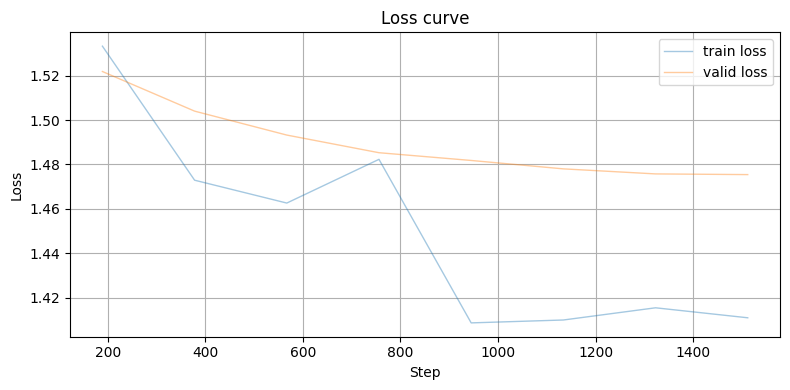

In [16]:
import pandas as pd
import matplotlib.pyplot as plt


logs = pd.DataFrame(trainer.state.log_history)

train = logs.loc[logs["loss"].notna(), ["step", "loss"]]
valid = logs.loc[logs["eval_loss"].notna(), ["step", "eval_loss"]]

plt.figure(figsize=(8,4))
plt.plot(train["step"][1:], train["loss"][1:], label="train loss", linewidth=1, alpha=0.4)
plt.plot(valid["step"], valid["eval_loss"], label="valid loss", linewidth=1, alpha=0.4)
plt.xlabel("Step");
plt.ylabel("Loss");
plt.title("Loss curve");
plt.legend();
plt.grid(True)
plt.tight_layout();
plt.show()


In [18]:
logs.to_csv("models/results/loss_log_llama3.2-1b.csv", index=False)

In [19]:
adapters_path = "models/llama3.2-1b"

tokenizer = AutoTokenizer.from_pretrained(adapters_path,padding_side="left", use_fast=True, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

model = AutoModelForCausalLM.from_pretrained(adapters_path,dtype=torch.float16,device_map='auto')
model.eval()
model.config.use_cache = True

In [20]:
@torch.inference_mode()
def generate_pls_llama_batch(
    data,
    batch_size: int = 1,
    max_new_tokens: int = 1024,
    temperature: float = 0.3,
    top_p: float = 0.9,
    num_beams: int = 1,
):

    texts = data['article'].fillna("").astype(str).tolist()
    df_out = data.copy()

    max_ctx = getattr(model.config, "max_position_embeddings", 4096)
    max_input_len = max(8, max_ctx - max_new_tokens)

    outputs = []

    pbar = tqdm(total=len(texts), desc='Generando resumenes', unit="sample")
    try:
        for i in range(0, len(texts), batch_size):
            batch_texts = texts[i:i + batch_size]
            prompts = [generar_prompt(t) for t in batch_texts]

            enc = tokenizer(
                prompts,
                return_tensors="pt",
                truncation=True,
                padding=True,
                max_length=max_input_len,
            )
            input_ids = enc["input_ids"].to(model.device)
            attention_mask = enc["attention_mask"].to(model.device)

            gen_ids = model.generate(
                input_ids=input_ids,
                attention_mask=attention_mask,
                max_new_tokens=max_new_tokens,
                do_sample=False,
                temperature=temperature,
                top_p=top_p,
                num_beams=num_beams,
                repetition_penalty=1.1,
                no_repeat_ngram_size=3,
                eos_token_id=tokenizer.eos_token_id,
                pad_token_id=tokenizer.pad_token_id,
                use_cache=True,
            )

            gen_only = gen_ids[0, input_ids.shape[1]:]
            text = tokenizer.decode(gen_only, skip_special_tokens=True).strip()
            outputs.append(text)
            pbar.update(len(batch_texts))
    finally:
      pbar.close()
    df_out['gen_summary'] = outputs
    return df_out


In [ ]:
import gc, torch


gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.ipc_collect()
    torch.cuda.reset_peak_memory_stats()

In [21]:
df_output = generate_pls_llama_batch(df_test)

Generando resumenes:   0%|          | 0/379 [00:00<?, ?sample/s]

The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


In [22]:
df_output.to_csv("models/results/summaries_llama3.2-1b.csv", index=False)